# End-to-End Pipeline Evaluation

Scores the notebooks 06_a/06_b models — classifier, segmenters, and the color
extraction they feed into — against the independent validation set built in
04_a/04_b: `data/annotations/labels_val.csv`.

Reported per class, on `block == 'core'` only for population-level ("ALL")
numbers — `type_boost` rows are a simple random draw within a shortfall type,
not an unconditional sample of the pool, so they're folded into the
**per-class** figures (more statistical power on the rare classes they exist
for) but kept out of the aggregate ones:

- **classifier accuracy** and **error rate** — Wilson score interval;
- **false-positive rate** and **false-negative rate** — Wilson;
- **segmentation IoU** — mean with a Student-$t$ interval;
- **ΔE CIE 2000** vs ground truth — mean and median with a $t$ interval, plus the
  ≤2.3 / 2.3–5 / >5 tier table from notebooks 06_a/06_b.

In [1]:
import os
import sys
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.color import lab2rgb

import torch

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = ('mps' if torch.backends.mps.is_available()
          else 'cuda' if torch.cuda.is_available()
          else 'cpu')

BASE       = os.path.abspath('../data')
ANN_DIR    = os.path.join(BASE, 'annotations')
CLEAN      = os.path.join(BASE, 'img', 'original_clean')
MODELS_DIR = os.path.abspath('../models')

# Repo root (not BASE, which points at data/ above) — needed to import the
# shared model-loading code in src/classify.py and src/segment.py.
REPO_ROOT = os.path.abspath('..')
sys.path.insert(0, REPO_ROOT)

print(f'device: {DEVICE}')


def find_image(img_name, img_dirs=(CLEAN,)):
    for d in img_dirs:
        p = os.path.join(d, img_name)
        if os.path.exists(p):
            return p
    return None


device: mps


In [2]:
labels_val_df = pd.read_csv(os.path.join(ANN_DIR, 'labels_val.csv'))
print(f'labels_val.csv: {len(labels_val_df)} rows, blocks: '
      f'{labels_val_df["block"].value_counts().to_dict()}')

labels_val.csv: 483 rows, blocks: {'core': 349, 'type_boost': 134}


In [3]:
# Classifier — see src/classify.py for the shared model + inference code,
# reused across notebooks so the loading logic can't drift between them.
# Class order always comes from the checkpoint itself, never hardcoded (CLAUDE.md).
from src.classify import load_classifier, predict as clf_predict

CLF_THRESHOLD = 0.6
clf, classes = load_classifier(os.path.join(MODELS_DIR, 'resnet18_classifier_al.pth'), device=DEVICE)
print(f'classifier loaded — classes: {classes}')


classifier loaded — classes: ['bullet', 'closed', 'lips', 'liquid', 'pencil', 'swatch', 'unclassifiable']


In [4]:
# Segmenters — see src/segment.py for the shared model + inference code. One
# U-Net architecture is shared by all four checkpoints; only the trained
# weights differ.
from src.segment import load_segmenter, predict_mask
# Color extraction from a mask — see src/extract_color.py.
from src.extract_color import extract_masked_color, extract_dominant_cluster_color
# Type -> segmenter + extraction-method routing table, shared with the
# production pipeline (08) so the two can't drift apart again.
from src.pipeline import route_and_extract, SEG_CLASSES
# Evaluation metrics — see src/metrics.py. mask_iou is unrelated to 06_b's
# batch_iou (different job, see that module's docstring).
from src.metrics import delta_e, mean_ci, mask_iou

seg        = load_segmenter(os.path.join(MODELS_DIR, 'unet_segmenter.pth'), device=DEVICE)
seg_other  = load_segmenter(os.path.join(MODELS_DIR, 'unet_segmenter_other.pth'), device=DEVICE)
seg_swatch = load_segmenter(os.path.join(MODELS_DIR, 'unet_swatch.pth'), device=DEVICE)
seg_lips   = load_segmenter(os.path.join(MODELS_DIR, 'unet_lips.pth'), device=DEVICE)

# Keyed by role, not filename — this is what route_and_extract expects.
segmenters = {'main': seg, 'closed': seg_other, 'swatch': seg_swatch, 'lips': seg_lips}


def lab_swatch(lab, size=(60, 60)):
    """A solid-color patch for display from a single Lab triple, or None if
    the color is missing (empty mask, no ground truth, etc.)."""
    if lab is None or np.any(pd.isna(lab)):
        return None
    rgb = lab2rgb(np.array(lab, dtype=float).reshape(1, 1, 3))
    return np.tile(rgb, (size[0], size[1], 1))


def show_swatch(ax, lab):
    """Draw a color swatch, or an explicit 'N/A' placeholder if the color is
    missing — never a plain gray box, which reads as a real pale/gray color
    reading rather than "no data" (this bit us once already)."""
    swatch = lab_swatch(lab)
    if swatch is None:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
    else:
        ax.imshow(swatch)


print('segmenters loaded — ready to evaluate')


segmenters loaded — ready to evaluate


### Routing logic

Once a segmenter (from `06_b_model_segmenters.ipynb`) produces a mask, the color-extraction method depends on presentation type:
- `bullet` / `liquid` / `pencil` → combined U-Net mask → median LAB from masked pixels
- `closed` → separate U-Net mask → dominant cluster LAB from masked pixels
- `swatch` → U-Net mask → median LAB from masked pixels
- `lips` → U-Net mask → median LAB from masked pixels
- `unclassifiable` → no extraction (trained class, not a confidence-threshold guess)
- confidence < 0.6 for any classifier prediction → no extraction, same as `unclassifiable`: a secondary safety net for images that don't even resemble the trained `unclassifiable` examples

This routing is evaluated end-to-end below against ground truth, so the choice of extraction method per type is driven by the real ΔE results here rather than decided in advance.

### Is `CLF_THRESHOLD` (0.6) actually helping?

For every validation row where the classifier's top-1 confidence falls below `CLF_THRESHOLD` and gets overridden to `unclassifiable`, check what would have happened if the top-1 guess had been trusted anyway, and how big the gap is to the runner-up prediction (the margin):

- **harmful discard** — top-1 was already correct; overriding it just throws away a right answer.
- **inconsequential** — top-1 was "wrong" but the true label routes through the same segmenter + extraction method anyway (e.g. confusing `bullet`/`pencil`, both in `SEG_CLASSES`), so the override changes nothing about the actual output.
- **good catch (avoided misroute)** — top-1 would have sent the image through the wrong segmenter entirely.
- **good catch (genuinely unclassifiable)** — the true label really is `unclassifiable`, and the threshold caught what the top-1 guess missed.


In [5]:
def route_group(label):
    return 'main' if label in SEG_CLASSES else label


def threshold_category(pred_label, true_label):
    if pred_label == true_label:
        return 'harmful discard (top-1 was correct)'
    if route_group(pred_label) == route_group(true_label):
        return 'inconsequential (same routing group)'
    if true_label == 'unclassifiable':
        return 'good catch (genuinely unclassifiable)'
    return 'good catch (avoided misroute)'


margin_rows = []
for _, row in labels_val_df.iterrows():
    ip = find_image(row['img_name_disk'])
    if ip is None:
        continue
    pred_label, conf, probs = clf_predict(clf, ip, classes, DEVICE)
    if conf >= CLF_THRESHOLD or pred_label == 'unclassifiable':
        continue  # not actually overridden by the threshold
    order = np.argsort(probs)[::-1]
    runner_up_label = classes[order[1]]
    runner_up_conf = float(probs[order[1]])
    margin_rows.append({
        'category': threshold_category(pred_label, row['label']),
        'pred_label': pred_label, 'confidence': conf,
        'runner_up_label': runner_up_label, 'runner_up_conf': runner_up_conf,
        'margin': conf - runner_up_conf, 'true_label': row['label'],
    })

margin_df = pd.DataFrame(margin_rows)
print(f'{len(margin_df)} validation rows actually overridden by CLF_THRESHOLD (of {len(labels_val_df)} total)\n')
print(margin_df[['category', 'pred_label', 'confidence', 'runner_up_label', 'runner_up_conf', 'margin', 'true_label']]
      .sort_values(['category', 'margin']).to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print()
print(margin_df.groupby('category')['margin'].agg(['count', 'mean', 'median', 'min', 'max']).round(3).to_string())


24 validation rows actually overridden by CLF_THRESHOLD (of 483 total)

                             category pred_label  confidence runner_up_label  runner_up_conf  margin     true_label
        good catch (avoided misroute)     bullet       0.430          closed           0.417   0.013         swatch
        good catch (avoided misroute)     closed       0.232            lips           0.208   0.024         swatch
        good catch (avoided misroute)     closed       0.378          liquid           0.352   0.026         liquid
        good catch (avoided misroute)     liquid       0.438  unclassifiable           0.411   0.027         closed
        good catch (avoided misroute)     bullet       0.279          liquid           0.246   0.033         swatch
        good catch (avoided misroute)     liquid       0.480  unclassifiable           0.324   0.155         closed
        good catch (avoided misroute)     bullet       0.463          closed           0.247   0.216         swatch


**Decision: leave `CLF_THRESHOLD` as a plain 0.6 cutoff.** The margin doesn't cleanly separate the categories above — harmful discards (top-1 already correct) and genuinely-unclassifiable catches have *similar*, if not larger, margins than the misroutes the threshold is meant to catch, so a margin-based refinement isn't obviously better with what's here. More importantly, this is a **24-row sample**. Pooling in the training set (`labels.csv`, 392 rows) doesn't help either — 0 of those rows fall below 0.6 confidence at all, since the classifier has already seen them during training, so it adds no new data points to this analysis, only dilutes the rate. Twenty-four rows is too small to tune a second parameter (a margin cutoff) with any confidence.

For now, the plain threshold stays: it discards some already-correct classifications (9 of the 24 cases here) in exchange for catching real misroutes and genuinely unclassifiable images (13 of 24) — an acceptable trade at this sample size. Revisit with a margin-based rule if/when a larger labeled sample (a future annotation round, or `labels_val.csv` growing) makes that tradeoff measurable rather than anecdotal.


In [6]:
def evaluate(labels_df):
    recs = []
    for _, row in labels_df.iterrows():
        ip = find_image(row['img_name_disk'])
        if ip is None:
            continue
        pred_label, conf, _ = clf_predict(clf, ip, classes, DEVICE)
        routed = pred_label if conf >= CLF_THRESHOLD else 'unclassifiable'
        mask_pred, lab_pred = route_and_extract(ip, routed, segmenters, DEVICE)
        pred_mask_empty = np.nan if mask_pred is None else float(mask_pred.sum() == 0)
        _, lab_gt = route_and_extract(ip, row['label'], segmenters, DEVICE)  # GT-routed: isolates segmenter quality

        iou = np.nan
        gt_mask = None
        mp = row.get('mask_path')
        if isinstance(mp, str) and os.path.exists(mp) and row['label'] != 'unclassifiable':
            gt_mask = (np.array(Image.open(mp).convert('L')) > 127).astype(np.uint8)
            pr_mask = predict_mask(
                segmenters['swatch'] if row['label'] == 'swatch' else
                segmenters['main'] if row['label'] in SEG_CLASSES else
                segmenters['closed'] if row['label'] == 'closed' else
                segmenters['lips'], ip, DEVICE)
            if pr_mask.shape != gt_mask.shape:
                pr_mask = np.array(Image.fromarray(pr_mask * 255).resize(
                    gt_mask.shape[::-1], Image.NEAREST)) // 255
            iou = mask_iou(pr_mask, gt_mask)

        # closed uses dominant-cluster extraction (src/pipeline.py), so its
        # ground truth must be dominant-cluster from the same hand-drawn mask
        # too -- comparing a cluster prediction against labels_val.csv's
        # median-only true_L/a/b biases ΔE toward "wrong" regardless of real
        # quality (see the Section 2 methodology note on extraction methods).
        tl = None
        if row['label'] == 'closed' and gt_mask is not None:
            img_arr = np.array(Image.open(ip).convert('RGB'))
            gtm = gt_mask
            if gtm.shape != img_arr.shape[:2]:
                gtm = np.array(Image.fromarray(gtm * 255).resize(
                    img_arr.shape[1::-1], Image.NEAREST)) // 255
            tl = extract_dominant_cluster_color(img_arr, gtm)
        elif pd.notna(row.get('true_L')):
            tl = [row['true_L'], row['true_a'], row['true_b']]

        de_pred = de_gt = np.nan
        if tl is not None:
            if not np.isnan(lab_pred).any():
                de_pred = delta_e(lab_pred, tl)
            if not np.isnan(lab_gt).any():
                de_gt = delta_e(lab_gt, tl)

        recs.append({
            'img_name_disk': row['img_name_disk'], 'block': row['block'],
            'true_label': row['label'], 'pred_label': pred_label, 'confidence': conf,
            'routed_label': routed, 'routed_correct': routed == row['label'],
            'iou': iou, 'delta_e_pred_routed': de_pred, 'delta_e_gt_routed': de_gt,
            'pred_mask_empty': pred_mask_empty,
        })
    return pd.DataFrame(recs)


val_eval = evaluate(labels_val_df)
_bc = val_eval['block'].value_counts().to_dict()
print(f'evaluated {len(val_eval)} validation images — blocks: {_bc}')


evaluated 483 validation images — blocks: {'core': 349, 'type_boost': 134}


In [7]:
# type_boost is not an unconditional sample of the pool, so it's excluded from
# the aggregate IoU/ΔE population estimates below ("ALL (core)"). Classifier-only
# metrics (confusion matrix, classification_report, per-class accuracy/FN/FP)
# now live in 06_a_model_classifier.ipynb; core/all_rows here feed the
# end-to-end segmentation IoU and ΔE analysis instead.
core = val_eval[val_eval['block'] == 'core']
all_rows = val_eval

## 1. Classification & Routing Accuracy

How much does a routing mistake actually cost, in segmentation quality and
color accuracy? For each group (correctly classified, incorrectly
classified, all), IoU is always the GT-routed segmenter's quality (what
segmentation would look like with the right route) and ΔE is
predicted-routed (the real color error the pipeline actually produces) —
so for correctly-classified images the two routes are the same thing, and
for misclassified ones the gap between them is the cost of the routing
error. 'n/a' means the group has no valid values (e.g. 'unclassifiable'
has no segmenter, so no IoU/ΔE at all). Overall uses the core block only;
by-category also folds in type_boost, for more power on the rare classes
(see the intro cell).

In [8]:
def results_table(df):
    """One row per group (correctly classified / incorrectly classified /
    all) with N, GT-routed segmentation IoU, and predicted-routed ΔE CIE 2000
    — each with a 95% CI."""
    total = len(df)
    groups = {
        'Correctly classified': df[df['routed_correct']],
        'Incorrectly classified': df[~df['routed_correct']],
        'All': df,
    }
    rows = []
    for name, g in groups.items():
        iou_m, iou_lo, iou_hi = mean_ci(g['iou'])
        de_m, de_lo, de_hi = mean_ci(g['delta_e_pred_routed'])
        rows.append({
            'group': name,
            'n': len(g),
            'pct': f'{len(g) / total * 100:.1f}%' if total else 'n/a',
            'iou': f'{iou_m:.3f} [{iou_lo:.3f}, {iou_hi:.3f}]' if pd.notna(iou_m) else 'n/a',
            'delta_e': f'{de_m:.2f} [{de_lo:.2f}, {de_hi:.2f}]' if pd.notna(de_m) else 'n/a',
        })
    return pd.DataFrame(rows).set_index('group')


print('OVERALL (core)\n')
print(results_table(core).to_string())

print('\nBY TRUE CATEGORY (core + type_boost)\n')
for c in classes:
    sub = all_rows[all_rows['true_label'] == c]
    if sub.empty:
        continue
    print(f'--- {c} (n={len(sub)}) ---')
    print(results_table(sub).to_string())
    print()


OVERALL (core)

                          n     pct                   iou             delta_e
group                                                                        
Correctly classified    318   91.1%  0.827 [0.806, 0.848]   0.83 [0.55, 1.11]
Incorrectly classified   31    8.9%  0.511 [0.370, 0.652]  9.84 [1.94, 17.73]
All                     349  100.0%  0.803 [0.779, 0.827]   1.06 [0.71, 1.40]

BY TRUE CATEGORY (core + type_boost)

--- bullet (n=127) ---
                          n     pct                    iou            delta_e
group                                                                        
Correctly classified    123   96.9%   0.808 [0.776, 0.840]  0.73 [0.59, 0.87]
Incorrectly classified    4    3.1%  0.553 [-0.066, 1.171]                n/a
All                     127  100.0%   0.800 [0.766, 0.833]  0.75 [0.60, 0.90]

--- closed (n=17) ---
                         n     pct                   iou             delta_e
group                                     

## 2. Segmentation IoU & ΔE by Type

Color-extraction quality in isolation, independent of routing mistakes: IoU
per type (ground-truth-routed, so it isolates segmenter quality on its own)
and ΔE CIE 2000 per type (predicted-routed, the real color error the
pipeline produces end-to-end), plus a tier breakdown against the 2.3 JND
threshold and the ΔE-by-type distribution below.

SEGMENTATION IoU — GT-routed, per type (core + type_boost)

  swatch   n=171   IoU 0.882  95% CI [0.859, 0.905]
  bullet   n=127   IoU 0.800  95% CI [0.766, 0.833]
  liquid   n=103   IoU 0.638  95% CI [0.591, 0.686]
  pencil   n= 24   IoU 0.450  95% CI [0.337, 0.563]
  closed   n= 17   IoU 0.761  95% CI [0.707, 0.816]
  ALL (core)   n=339   IoU 0.803  95% CI [0.779, 0.827]

ΔE CIE 2000 vs ground truth — predicted-routed, per type

  swatch   n=150   mean 0.42 [0.15, 0.69]   median 0.07
  bullet   n=123   mean 0.75 [0.60, 0.90]   median 0.45
  liquid   n= 95   mean 2.05 [1.14, 2.96]   median 0.65
  pencil   n= 20   mean 3.65 [0.51, 6.79]   median 0.75
  closed   n= 12   mean 1.92 [-0.72, 4.55]   median 0.44
  lips     n= 12   mean 1.96 [-0.88, 4.79]   median 0.46
  ALL (core)   n=320   mean 1.06 [0.71, 1.40]   median 0.29
  ALL (core+boost) n=412   mean 1.14 [0.84, 1.44]   median 0.31

ΔE tier breakdown (predicted-routed, core only):
delta_e_pred_routed
<= 2.3 (great)    91.2
2.3-5 (ok)

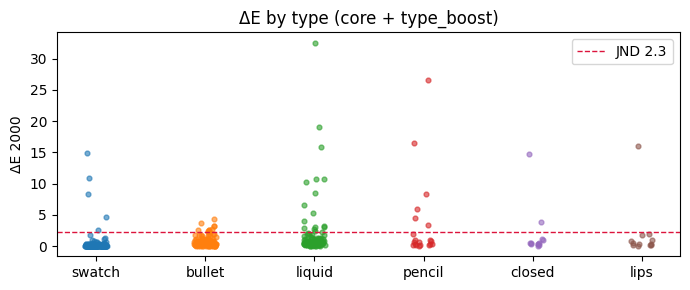

In [9]:
print('SEGMENTATION IoU — GT-routed, per type (core + type_boost)\n')
for c in ['swatch', 'bullet', 'liquid', 'pencil', 'closed']:
    m, lo, hi = mean_ci(all_rows.loc[all_rows['true_label'] == c, 'iou'])
    n = all_rows.loc[all_rows['true_label'] == c, 'iou'].notna().sum()
    print(f'  {c:8s} n={n:3d}   IoU {m:.3f}  95% CI [{lo:.3f}, {hi:.3f}]')
m, lo, hi = mean_ci(core['iou'])
print(f'  {"ALL (core)":12s} n={core["iou"].notna().sum():3d}   IoU {m:.3f}  95% CI [{lo:.3f}, {hi:.3f}]')

print('\nΔE CIE 2000 vs ground truth — predicted-routed, per type\n')
for c in ['swatch', 'bullet', 'liquid', 'pencil', 'closed', 'lips']:
    d = all_rows.loc[all_rows['true_label'] == c, 'delta_e_pred_routed']
    m, lo, hi = mean_ci(d)
    md_ = d.dropna().median()
    print(f'  {c:8s} n={d.notna().sum():3d}   mean {m:.2f} [{lo:.2f}, {hi:.2f}]   median {md_:.2f}')
d = core['delta_e_pred_routed']
m, lo, hi = mean_ci(d)
print(f'  {"ALL (core)":12s} n={d.notna().sum():3d}   mean {m:.2f} [{lo:.2f}, {hi:.2f}]   median {d.dropna().median():.2f}')
d_all = all_rows['delta_e_pred_routed']
m, lo, hi = mean_ci(d_all)
print(f'  {"ALL (core+boost)":16s} n={d_all.notna().sum():3d}   mean {m:.2f} [{lo:.2f}, {hi:.2f}]   median {d_all.dropna().median():.2f}')

print('\nΔE tier breakdown (predicted-routed, core only):')
tier = pd.cut(core['delta_e_pred_routed'].dropna(), [-0.1, 2.3, 5, 1e9],
              labels=['<= 2.3 (great)', '2.3-5 (ok)', '> 5 (poor)'])
print((tier.value_counts(normalize=True).reindex(['<= 2.3 (great)', '2.3-5 (ok)', '> 5 (poor)']) * 100).round(1).to_string())

# core + type_boost: the full evaluated sample, oversampled on rare types for
# subgroup power. Not an unconditional draw from the pool (see note above), so
# this headline number is optimistic relative to the population's true rate --
# reported alongside the core-only rate rather than in place of it.
print('\nΔE tier breakdown (predicted-routed, core + type_boost):')
tier_all = pd.cut(all_rows['delta_e_pred_routed'].dropna(), [-0.1, 2.3, 5, 1e9],
                   labels=['<= 2.3 (great)', '2.3-5 (ok)', '> 5 (poor)'])
print((tier_all.value_counts(normalize=True).reindex(['<= 2.3 (great)', '2.3-5 (ok)', '> 5 (poor)']) * 100).round(1).to_string())

d = all_rows['delta_e_pred_routed'].dropna()
if len(d):
    fig, ax = plt.subplots(figsize=(7, 3))
    for i, c in enumerate(['swatch', 'bullet', 'liquid', 'pencil', 'closed', 'lips']):
        y = all_rows.loc[all_rows['true_label'] == c, 'delta_e_pred_routed'].dropna()
        ax.scatter(np.full(len(y), i) + np.random.uniform(-0.1, 0.1, len(y)), y, s=12, alpha=0.6)
    ax.axhline(2.3, color='crimson', ls='--', lw=1, label='JND 2.3')
    ax.set_xticks(range(6)); ax.set_xticklabels(['swatch', 'bullet', 'liquid', 'pencil', 'closed', 'lips'])
    ax.set_ylabel('ΔE 2000'); ax.legend(); ax.set_title('ΔE by type (core + type_boost)')
    plt.tight_layout(); plt.show()

### Extraction method: median vs. dominant cluster, by type

`src/pipeline.py` currently assigns plain median extraction to every type
except `closed` (dominant cluster, chosen to resist glare/reflection). The
boxplots below check that assignment empirically, type by type: for every
type, both methods are applied to the same GT-routed predicted mask (the
correct segmenter for that row's true label), each scored against a ground
truth computed the *same way* as the method being tested -- a dominant-
cluster prediction is compared against a dominant-cluster ground truth (from
the same hand-drawn mask), not against `labels_val.csv`'s median-only
`true_L/a/b`, which would bias the result toward median regardless of which
method is actually better.


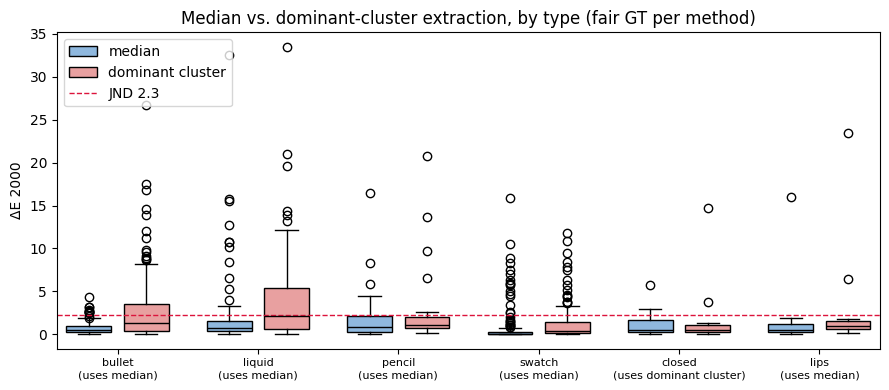

           median                      dominant_cluster                       \
           median   iqr pct_jnd      n           median   iqr pct_jnd      n   
true_label                                                                     
bullet       0.45  0.67   92.80  125.0             1.36  3.16   63.20  125.0   
liquid       0.68  1.20   82.83   99.0             2.12  4.77   51.52   99.0   
pencil       0.83  1.81   78.26   23.0             1.13  1.25   78.26   23.0   
swatch       0.08  0.29   90.64  171.0             0.40  1.27   83.63  171.0   
closed       0.54  1.32   88.24   17.0             0.52  0.82   88.24   17.0   
lips         0.46  1.02   91.67   12.0             1.00  0.95   83.33   12.0   

                              
              currently_uses  
true_label                    
bullet                median  
liquid                median  
pencil                median  
swatch                median  
closed      dominant cluster  
lips                  median  


In [10]:
SEG_FOR_TYPE = {
    'bullet': 'main', 'liquid': 'main', 'pencil': 'main',
    'swatch': 'swatch', 'closed': 'closed', 'lips': 'lips',
}
CURRENT_METHOD = {t: ('dominant cluster' if t == 'closed' else 'median') for t in SEG_FOR_TYPE}

# Ground truth must be computed the SAME way as whatever prediction method is
# being scored -- comparing a dominant-cluster prediction against a
# median-based ground truth biases the result toward median regardless of
# which is actually the better color, since the "truth" would itself be a
# median. So this recomputes a dominant-cluster ground truth from the same
# hand-drawn mask, instead of reusing labels_val.csv's median-only true_L/a/b
# for both comparisons.
method_rows = []
for _, row in labels_val_df.iterrows():
    if pd.isna(row['true_L']) or row['label'] not in SEG_FOR_TYPE:
        continue
    mp = row.get('mask_path')
    if not isinstance(mp, str) or not os.path.exists(mp):
        continue
    img_path = find_image(row['img_name_disk'])
    if img_path is None:
        continue
    img = np.array(Image.open(img_path).convert('RGB'))

    gt_mask = (np.array(Image.open(mp).convert('L')) > 127).astype(np.uint8)
    if gt_mask.shape != img.shape[:2]:
        gt_mask = np.array(Image.fromarray(gt_mask * 255).resize(
            img.shape[1::-1], Image.NEAREST)) // 255
    true_median = np.array([row['true_L'], row['true_a'], row['true_b']])  # 04_b's ground truth
    true_cluster = extract_dominant_cluster_color(img, gt_mask)  # same GT mask, cluster method

    pred_mask = predict_mask(segmenters[SEG_FOR_TYPE[row['label']]], img_path, DEVICE)
    method_rows.append({
        'true_label': row['label'],
        'de_median':  delta_e(extract_masked_color(img, pred_mask), true_median),
        'de_cluster': delta_e(extract_dominant_cluster_color(img, pred_mask), true_cluster),
    })
method_df = pd.DataFrame(method_rows)

types = ['bullet', 'liquid', 'pencil', 'swatch', 'closed', 'lips']
pos_median = np.arange(len(types)) * 2.2
pos_cluster = pos_median + 0.9

fig, ax = plt.subplots(figsize=(9, 4))
bp1 = ax.boxplot([method_df.loc[method_df['true_label'] == t, 'de_median'].dropna() for t in types],
                  positions=pos_median, widths=0.7, patch_artist=True,
                  boxprops=dict(facecolor='#8fb8de'), medianprops=dict(color='black'))
bp2 = ax.boxplot([method_df.loc[method_df['true_label'] == t, 'de_cluster'].dropna() for t in types],
                  positions=pos_cluster, widths=0.7, patch_artist=True,
                  boxprops=dict(facecolor='#e8a0a0'), medianprops=dict(color='black'))
ax.axhline(2.3, color='crimson', ls='--', lw=1, label='JND 2.3')
ax.set_xticks(pos_median + 0.45)
ax.set_xticklabels([f'{t}\n(uses {CURRENT_METHOD[t]})' for t in types], fontsize=8)
ax.set_ylabel('ΔE 2000')
ax.legend([bp1['boxes'][0], bp2['boxes'][0], ax.lines[-1]], ['median', 'dominant cluster', 'JND 2.3'], loc='upper left')
ax.set_title('Median vs. dominant-cluster extraction, by type (fair GT per method)')
plt.tight_layout()
plt.show()

# A single "better" verdict from the median alone hides the real tradeoff --
# check spread (IQR: middle-50% width) and the actual pass/fail bar this
# project uses (% within the 2.3 JND) too, not just central tendency.
def _stats(s):
    s = s.dropna()
    iqr = s.quantile(.75) - s.quantile(.25)
    return pd.Series({'median': s.median(), 'iqr': iqr, 'pct_jnd': (s <= 2.3).mean() * 100, 'n': len(s)})

summary = pd.concat(
    {'median': method_df.groupby('true_label')['de_median'].apply(_stats).unstack(),
     'dominant_cluster': method_df.groupby('true_label')['de_cluster'].apply(_stats).unstack()},
    axis=1,
).reindex(types)
summary[('', 'currently_uses')] = [CURRENT_METHOD[t] for t in types]
print(summary.round(2))


## 3. Unclassifiable Images

`unclassifiable` covers two different cases: `color_not_shown` (sealed
container, nothing visible) and `multi_impage` (a composite showing several
product versions or a palette, not a single clean shot). Neither has a
coherent single color by convention, so the sections below look at what
happens when the classifier fails to catch one of these and routes it to a
real extractor anyway.

### Routed to a real class instead of unclassifiable

The costliest classifier mistake isn't confusing two extractable types — it's
missing `unclassifiable` entirely, which sends a sealed/multi-product image
through a color extractor that has nothing meaningful to extract. Every
validation image with true label `unclassifiable` that was actually routed
to a real extractor (i.e. the `CLF_THRESHOLD` safety net didn't catch it
either), grouped by what it was routed to, with the color that got extracted.


13 unclassifiable images routed to a real extractor

routed_label
liquid    5
closed    4
pencil    2
bullet    1
lips      1


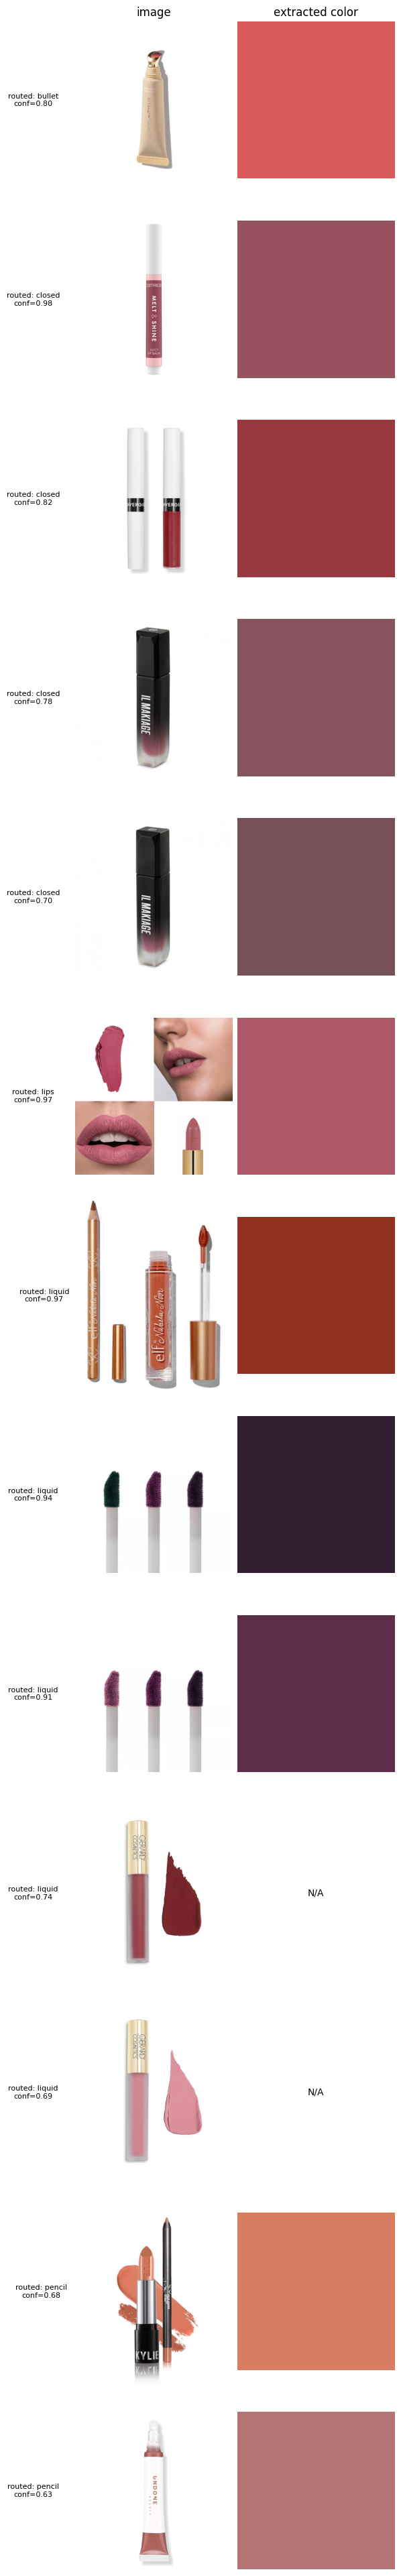

In [11]:
misrouted = all_rows[(all_rows['true_label'] == 'unclassifiable') &
                     (all_rows['routed_label'] != 'unclassifiable')]
misrouted = misrouted.sort_values(['routed_label', 'confidence'], ascending=[True, False])

if misrouted.empty:
    print('no unclassifiable images were routed to a real extractor')
else:
    print(f'{len(misrouted)} unclassifiable images routed to a real extractor\n')
    print(misrouted['routed_label'].value_counts().to_string())

    n = len(misrouted)
    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n))
    axes = np.atleast_2d(axes)
    for i, (_, row) in enumerate(misrouted.iterrows()):
        img_path = find_image(row['img_name_disk'])
        _, lab_pred = route_and_extract(img_path, row['routed_label'], segmenters, DEVICE)

        axes[i, 0].imshow(Image.open(img_path).convert('RGB'))
        axes[i, 0].set_ylabel(f"routed: {row['routed_label']}\nconf={row['confidence']:.2f}",
                               fontsize=8, rotation=0, labelpad=45, va='center')
        show_swatch(axes[i, 1], lab_pred)
        for ax in (axes[i, 0], axes[i, 1]):
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

    axes[0, 0].set_title('image')
    axes[0, 1].set_title('extracted color')
    plt.tight_layout()
    plt.show()


### Composite unclassifiable images: does misrouting still get the color right?

A subset of `unclassifiable` images (raw label `multi_image`) are composites
showing the *same shade in multiple formats side by side* — e.g. bullet +
pencil + liquid, or product + swatch + lips — rather than the other
`unclassifiable` case (`color_not_shown`: sealed, nothing visible at all).
These composites still have a real hand-drawn mask over one color region,
even though the photo as a whole isn't a single clean product shot. When the
classifier confidently routes one of these to a real class instead of
`unclassifiable`, does the resulting extraction happen to land on the right
color anyway?

An empty predicted mask (no color extracted at all) is scored separately from a wrong color below. It's a safe failure (no answer), not a harmful one (a confidently wrong answer).


In [12]:
import glob
import json

# labels_val.csv only stores the remapped 'unclassifiable' label, so recover
# the original pre-remap label (multi_impage vs. color_not_shown) from the
# latest Label Studio export to isolate the composite images specifically.
_export = sorted(glob.glob(os.path.join(BASE, 'processed', 'project-*.json')), key=os.path.getmtime)[-1]
with open(_export) as f:
    _raw = json.load(f)

_raw_label_by_disk = {}
for _task in _raw:
    _name = os.path.basename(_task['data']['image'])
    _name = _name.split('-', 1)[-1] if '-' in _name else _name
    _ann = (_task.get('annotations') or [None])[0]
    if not _ann or not _ann.get('result'):
        continue
    _label = next((r['value']['brushlabels'][0] for r in _ann['result'] if r['value'].get('brushlabels')), None)
    _disk = find_image(os.path.splitext(_name)[0] + '.jpg')
    if _disk:
        _raw_label_by_disk[os.path.basename(_disk)] = _label

composites = labels_val_df[
    (labels_val_df['label'] == 'unclassifiable')
    & (labels_val_df['img_name_disk'].map(_raw_label_by_disk) == 'multi_impage')
    & labels_val_df['mask_path'].apply(lambda p: isinstance(p, str) and os.path.exists(p))
]
print(f'{len(composites)} composite (multi-version) unclassifiable images with a usable mask')

not_routed, empty_mask, wrong, correct = 0, 0, 0, 0
for _, row in composites.iterrows():
    img_path = find_image(row['img_name_disk'])
    img_arr = np.array(Image.open(img_path).convert('RGB'))
    mask_arr = (np.array(Image.open(row['mask_path']).convert('L')) > 127).astype(np.uint8)
    if mask_arr.shape != img_arr.shape[:2]:
        mask_arr = np.array(Image.fromarray(mask_arr * 255).resize(
            img_arr.shape[1::-1], Image.NEAREST)) // 255
    true_lab = extract_masked_color(img_arr, mask_arr)

    pred_label, conf, _ = clf_predict(clf, img_path, classes, DEVICE)
    routed = pred_label if conf >= CLF_THRESHOLD else 'unclassifiable'
    if routed == 'unclassifiable':
        not_routed += 1
        continue
    _, pred_lab = route_and_extract(img_path, routed, segmenters, DEVICE)
    if np.isnan(pred_lab).any():
        empty_mask += 1
    elif delta_e(pred_lab, true_lab) <= 2.3:
        correct += 1
    else:
        wrong += 1

n_routed = empty_mask + wrong + correct
not_harmful = correct + empty_mask  # a wrong color is worse than no color at all
print(f'{not_routed} correctly predicted unclassifiable directly (not routed)')
print(f'{n_routed} routed to a real class instead of unclassifiable:')
print(f'  {correct}/{n_routed} landed within the 2.3 JND of the true composite-mask color '
      f'({correct/n_routed:.0%})' if n_routed else '  (none)')
print(f'  {wrong} extracted a clearly wrong color, {empty_mask} produced an empty predicted mask '
      f'(no color at all -- not harmful, just no answer)')
print(f'  => {not_harmful}/{n_routed} misroutes were harmless (correct color or no color), '
      f'only {wrong}/{n_routed} actively gave a wrong color' if n_routed else '')


7 composite (multi-version) unclassifiable images with a usable mask


2 correctly predicted unclassifiable directly (not routed)
5 routed to a real class instead of unclassifiable:
  2/5 landed within the 2.3 JND of the true composite-mask color (40%)
  1 extracted a clearly wrong color, 2 produced an empty predicted mask (no color at all -- not harmful, just no answer)
  => 4/5 misroutes were harmless (correct color or no color), only 1/5 actively gave a wrong color


## 4. Largest Individual Errors

Failure modes below the aggregate numbers: masks the segmenter couldn't find
anything for, and the specific images with the biggest color errors.

### Empty predicted masks

Among images where a mask was actually attempted (i.e. not routed to
`unclassifiable`), what fraction come back completely empty? The segmenter
found nothing above threshold anywhere in the image, forcing color
extraction to fall back with no signal at all. Broken down by the predicted
(routed) type and by the annotated (true) type, since an empty mask can come
from either a hard image for that true type or a bad route to the wrong
segmenter.


In [13]:
has_mask = all_rows['pred_mask_empty'].notna()
pct_empty_overall = all_rows.loc[has_mask, 'pred_mask_empty'].mean() * 100
print(f'overall: {pct_empty_overall:.1f}% of {has_mask.sum()} attempted masks are empty\n')


def _pct_empty_by(group_col):
    g = (all_rows[has_mask].groupby(group_col)['pred_mask_empty']
         .agg(['mean', 'count'])
         .rename(columns={'mean': 'pct_empty', 'count': 'n'}))
    g['pct_empty'] *= 100
    return g


print('by predicted (routed) type:')
print(_pct_empty_by('routed_label').to_string(float_format=lambda x: f'{x:.1f}'))

print('\nby annotated (true) type:')
print(_pct_empty_by('true_label').to_string(float_format=lambda x: f'{x:.1f}'))


overall: 2.8% of 435 attempted masks are empty

by predicted (routed) type:
              pct_empty    n
routed_label                
bullet              6.5  138
closed              0.0   20
lips                0.0   13
liquid              3.1   97
pencil              0.0   19
swatch              0.0  148

by annotated (true) type:
                pct_empty    n
true_label                    
bullet                0.8  124
closed                7.7   13
lips                  0.0   12
liquid                3.1   98
pencil                0.0   20
swatch                3.2  155
unclassifiable       15.4   13


### Largest color errors, by type

Every image with predicted-routed ΔE CIE 2000 over `DELTA_E_BAD`, grouped by
type — a spot-check on what's actually going wrong (wrong route, bad mask, an
unusual photo) rather than just the summary number.


In [14]:
DELTA_E_BAD = 5  # "poor" tier from the breakdown above

bad = all_rows[all_rows['delta_e_pred_routed'] > DELTA_E_BAD].sort_values(
    ['true_label', 'delta_e_pred_routed'], ascending=[True, False])

if bad.empty:
    print(f'no images with ΔE > {DELTA_E_BAD}')
else:
    print(f'{len(bad)} images with ΔE > {DELTA_E_BAD}\n')
    print(bad['true_label'].value_counts().to_string())


18 images with ΔE > 5

true_label
liquid    9
pencil    4
swatch    3
closed    1
lips      1


### Largest color errors — image, masks, and colors

One row per image from the ΔE > `DELTA_E_BAD` set above: the original image,
its ground-truth mask, the mask actually used for the predicted color (from
`routed_label`), and a swatch of the true vs. predicted color side by side —
to see whether the failure is a bad mask, a misroute, or just a bad color
read within an otherwise-correct mask.


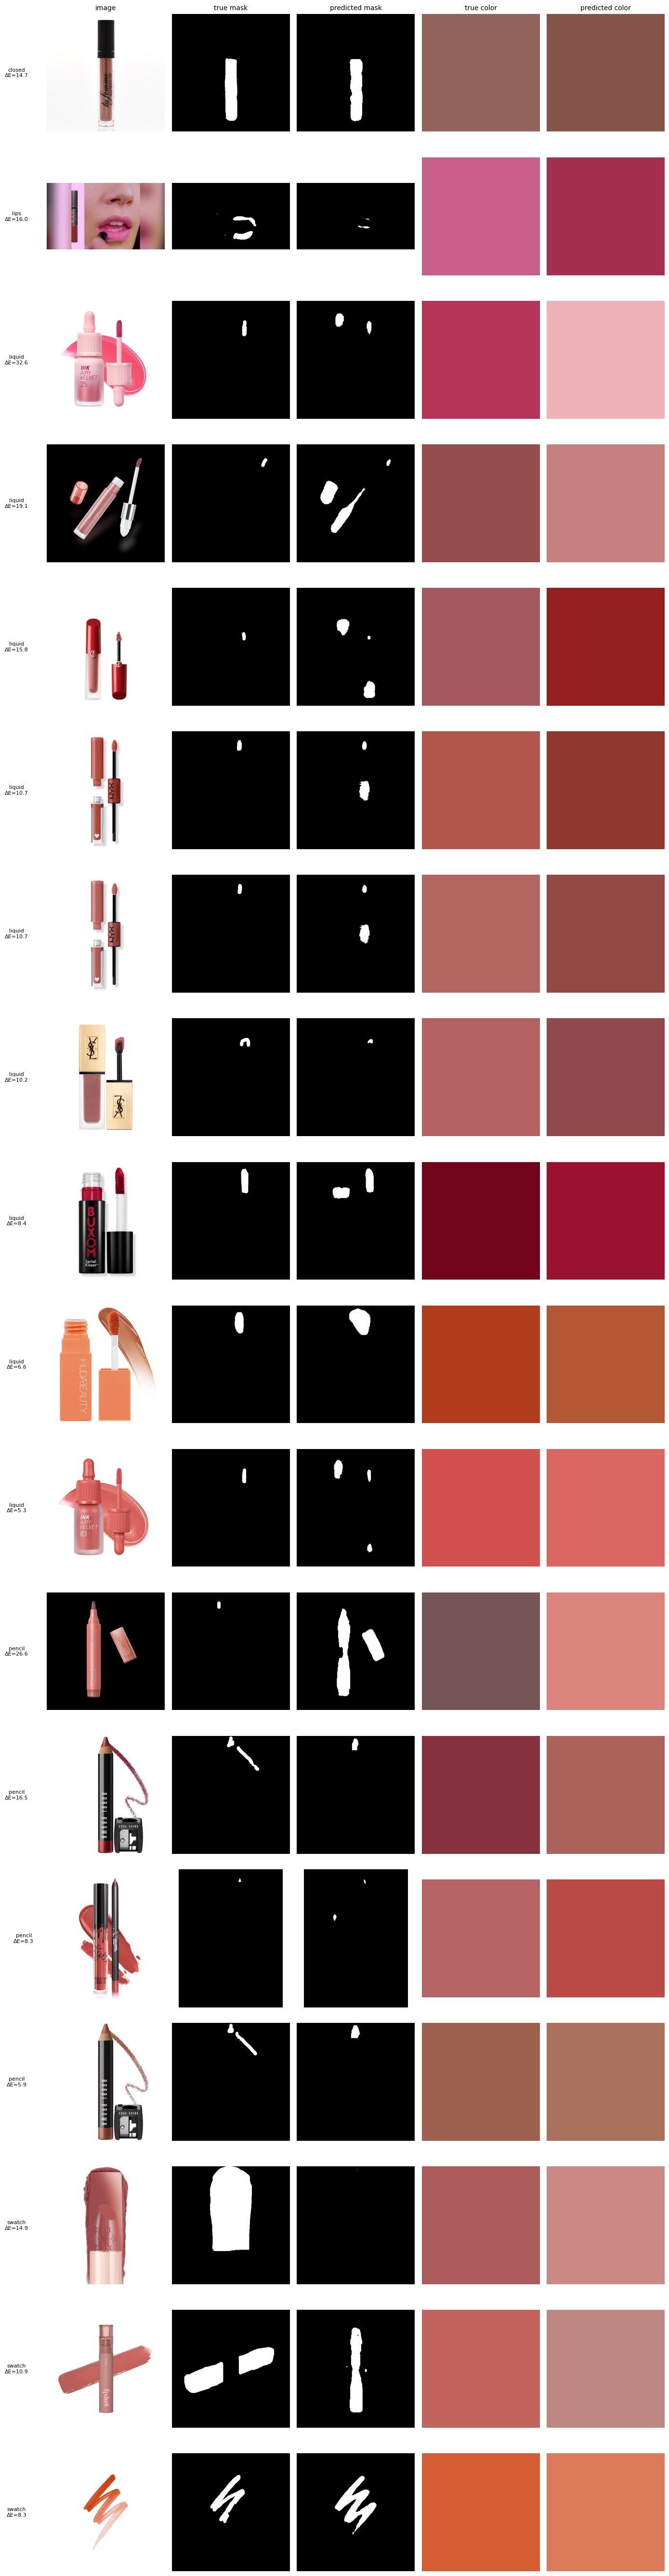

In [15]:
bad_rows = bad.reset_index(drop=True)
n = len(bad_rows)

if n == 0:
    print(f'no images with ΔE > {DELTA_E_BAD}')
else:
    col_titles = ['image', 'true mask', 'predicted mask', 'true color', 'predicted color']
    fig, axes = plt.subplots(n, 5, figsize=(14, 3 * n))
    axes = np.atleast_2d(axes)

    for i, row in bad_rows.iterrows():
        img_path = find_image(row['img_name_disk'])
        img = np.array(Image.open(img_path).convert('RGB'))
        lv = labels_val_df.loc[labels_val_df['img_name_disk'] == row['img_name_disk']].iloc[0]

        true_mask = None
        mp = lv.get('mask_path')
        if isinstance(mp, str) and os.path.exists(mp):
            true_mask = (np.array(Image.open(mp).convert('L')) > 127).astype(np.uint8)
            if true_mask.shape != img.shape[:2]:
                true_mask = np.array(Image.fromarray(true_mask * 255).resize(
                    (img.shape[1], img.shape[0]), Image.NEAREST)) // 255

        pred_mask, lab_pred = route_and_extract(img_path, row['routed_label'], segmenters, DEVICE)
        true_lab = [lv['true_L'], lv['true_a'], lv['true_b']] if pd.notna(lv['true_L']) else None

        axes[i, 0].imshow(img)
        axes[i, 1].imshow(true_mask, cmap='gray') if true_mask is not None else \
            axes[i, 1].text(0.5, 0.5, 'no mask', ha='center', va='center')
        axes[i, 2].imshow(pred_mask, cmap='gray') if pred_mask is not None else \
            axes[i, 2].text(0.5, 0.5, 'no mask', ha='center', va='center')
        show_swatch(axes[i, 3], true_lab)
        show_swatch(axes[i, 4], lab_pred)

        axes[i, 0].set_ylabel(f"{row['true_label']}\nΔE={row['delta_e_pred_routed']:.1f}",
                               fontsize=8, rotation=0, labelpad=45, va='center')
        for j in range(5):
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
            for spine in axes[i, j].spines.values():
                spine.set_visible(False)

    for j, t in enumerate(col_titles):
        axes[0, j].set_title(t, fontsize=10)

    plt.tight_layout()
    plt.show()


### Summary

On the independent validation set (core block, _N_ = `349`), the classifier
(`06_a_model_classifier.ipynb`) reached _`88.0`%_ overall accuracy (95% CI
`[0.85, 0.91]`). Per-class accuracy was lowest for `unclassifiable`
(`44.8%`, CI `[0.28, 0.62]`) which is a difficult class covering
very different visual patterns (sealed/nothing-visible containers,
multi-product composites, and stock photos). GT-routed segmentation IoU was
`0.803` overall.

Importantly, predicted-routed ΔE CIE 2000 had a median of `0.29` and
`91.2`% of images within the 2.3 JND threshold, meaning the extracted shade is visually a very cloase match to the ground truth shade.




## How to run

```bash
.venv/bin/python -m jupyter nbconvert --to notebook --execute --inplace \
  --ExecutePreprocessor.kernel_name=lipstick-venv \
  notebooks/07_end_to_end_evaluation.ipynb
```

The notebook's saved kernelspec is named `python3`, which on this machine resolves
to an unrelated venv — pass `--ExecutePreprocessor.kernel_name=lipstick-venv` explicitly
(check `jupyter kernelspec list` if this ever changes) or select that kernel by hand in
Jupyter's UI, otherwise imports like `skimage` fail with `ModuleNotFoundError`.

Requires notebooks 06_a/06_b's checkpoints in `models/` and `data/annotations/labels_val.csv`
from 04_b. Writes no files — prints metrics and displays plots in the notebook.